<a href="https://colab.research.google.com/github/OsvaldoCr99/Challenge-Introducci-n-a-las-Funciones-CRUD-de-Agenda-/blob/main/Challenge_Introducci%C3%B3n_a_la_Estad%C3%ADstica_Descriptiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **HANDS ON: INTRODUCCIÓN A ESTADÍSTICA DESCRIPTIVA**


Una vez visto la presentación ***Introducción a la estadística descriptiva***, se proporciona el siguiente ***colab*** para que **el alumnado pueda practicar** haciendo uso del lenguaje de programación ***python***.

De igual manera, se proporciona la **solución** de este notebook a través del siguiente [enlace](https://colab.research.google.com/drive/1Nt9D-SMIfCHgGkgwH6SYyUa26J5bJ1XV?usp=sharing).


## **ANÁLISIS UNIVARIABLE**

El **análisis univariable** es el análisis que se realiza a **una sola variable** a la vez. Su propósito principal es **describir la distribución, frecuencia y tendencia** de esa única característica, sin considerar relaciones de causa o efecto.

***NOTA:*** *Se hará el uso de las bibliotecas de **Pandas** y **Seaborn** para usar datasets precargados sin entrar a tanto detalle a las librerías mismas. Para ello, se explicará mas a detalle en el siguiente módulo.*

In [78]:
#Importar librerías

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [37]:
# Importar dataset

df_tips = sns.load_dataset('tips')
df_tips

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [38]:
# Mostrar propiedades de la tabla

df_tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [39]:
# Mostrar resumen estadístico

df_tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [40]:
# Realizar una proporción de probabilidad

media = round(df_tips.describe()['total_bill']['mean'], 4)
std= round(df_tips.describe()['total_bill']['std'], 4)
prop_prob = round((std/media)*100, 1)

print(f'Los datos se separan de la medía a un {prop_prob}%')

Los datos se separan de la medía a un 45.0%


#### **MEDIDAS DE TENDENCIA CENTRAL**

Las **medidas de tendencia central** (MTC) son métricas estadísticas que nos permiten **resumir un conjunto de datos en un solo valor**. Estas métricas nos indican cuál es el **valor que se encuentra en el centro** de un conjunto de datos.

Las medidas de tendencia central son:

*   **Media:** Es el valor promedio de un conjunto de datos y es muy sensible a los sesgos.

*   **Mediana:** Es el valor que se encuentra en el centro de un conjunto de datos ordenados y es menos sensible a los sesgos.

*   **Moda:** Es el valor que aparece con más frecuencia en un conjunto de datos.

In [41]:
# Definir variables

media = round(df_tips['total_bill'].mean(), 2)
mediana = round(df_tips['total_bill'].median(), 2)
moda = round(df_tips['total_bill'].mode().iloc[0], 2)

print(f'Las MTC son: media {media}, mediana {mediana} y moda {moda}')

Las MTC son: media 19.79, mediana 17.8 y moda 13.42


In [79]:
# Definir listas

mtc_datos = [moda, mediana, media]
mtc_nombres = ['moda', 'mediana', 'media']
mtc_colores = ['green', 'red', 'blue']

mtc_configuraciones = zip(mtc_datos, mtc_nombres, mtc_colores)

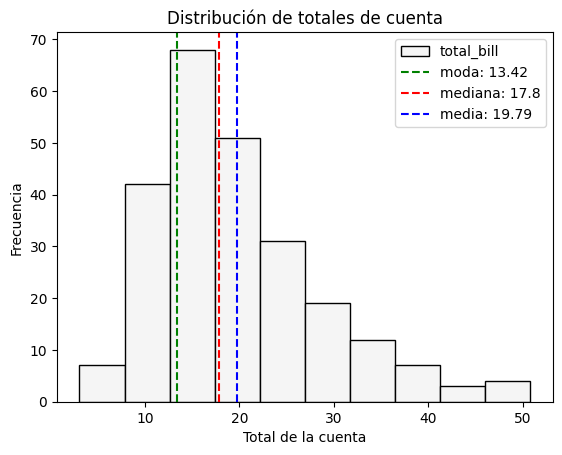

In [43]:
# Visualizar métricas de tendencia central

df_tips['total_bill'].plot(kind = 'hist', edgecolor = 'black', color = 'whitesmoke') #plt.hist(x = df_tips['total_bill'])
plt.title('Distribución de totales de cuenta')
plt.xlabel('Total de la cuenta')
plt.ylabel('Frecuencia')

for dato, nombre, color in mtc_configuraciones:
  plt.axvline(x = dato, c = color, linestyle = '--', label = f'{nombre}: {dato}')

plt.legend()
plt.show()

### **MEDIDAS DE DISPERSIÓN**

Las **medidas de dispersión** indican qué tan **extendidos o separados se encuentran los datos de una distribución** respecto a un valor central. Son fundamentales para determinar la **variabilidad y la confiabilidad** de un conjunto de datos.

Las métricas de disperción mas utilizadas son:

*   **Desviación estandar:** Es la media de las desviaciones de los datos, a mayor desviación los datos estarán más dispersos.

*   **Cuartíl:** Son los valores estadísticos que dividen una distribución en 4 partes iguales formando un **rango intercuartílico**.

#### **DESVIACIÓN ESTANDAR**

La **desviación estándar** es una medida de la dispersión de un conjunto de datos numéricos. Se calcula como la media de las desviaciones de los datos con respecto a la media.

Se interpreta como **la distancia promedio entre los datos y la media.** Una **desviación estándar baja** indica que los datos están agrupados cerca de la media, mientras que una **desviación estándar alta** indica que los datos están más dispersos.

In [80]:
# Definir variables

x = range(len(df_tips['total_bill']))
y = df_tips['total_bill']
std = np.std(df_tips['total_bill'])

In [45]:
# Definir listas

std_datos = [media, media + std, media - std]
std_nombres = ['media', 'desviación estándar', None]
std_colores = ['red', 'blue', 'blue']

std_configuraciones = zip(std_datos, std_nombres, std_colores)

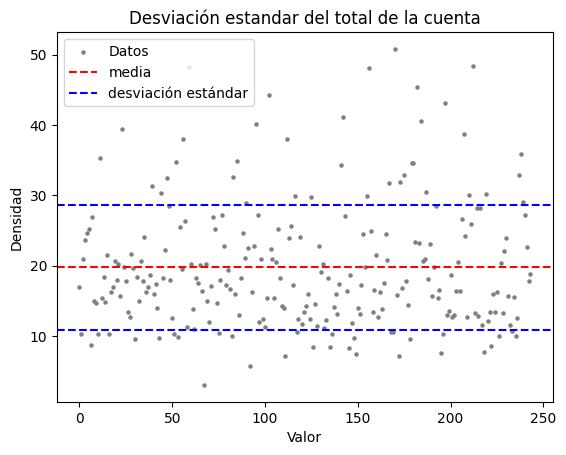

In [46]:
# Visualizar dipersión de los datos

plt.scatter(x, y, label = 'Datos', s = 5, color = 'gray')
plt.title('Desviación estandar del total de la cuenta')
plt.xlabel('Valor')
plt.ylabel('Densidad')

for dato, nombre, color in std_configuraciones:
    plt.axhline(y = dato, c = color, linestyle = '--', label = nombre)

plt.legend()
plt.show()

#### **PERCENTILES**

Los **percentiles** son valores estadísticos que dividen una distribución de datos en **100 partes iguales** (por el cual puede ser asociado como porcentaje). Se utilizan comúnmente en estadísticas y análisis de datos para entender la posición de un valor específico en relación con otros valores en un conjunto de datos.

Los percentiles pueden ser trabajados por **cuartiles**, el cual es dividir en **4 partes iguales** la misma distribución, siendo cada parte una agrupación del 25% de elementos de la distribución. Su gráfico mas representativo es el **gráfico de caja** y forma un **rango intercuartílico** (IQR) cuando se realiza la diferencia entre el primer y tercer cuartil.

In [47]:
# Definir variables

percentil = np.percentile(df_tips['total_bill'], [25, 50, 75])

q_1 = round(percentil[0], 2)
q_3 = round(percentil[2], 2)
iqr = q_3 - q_1

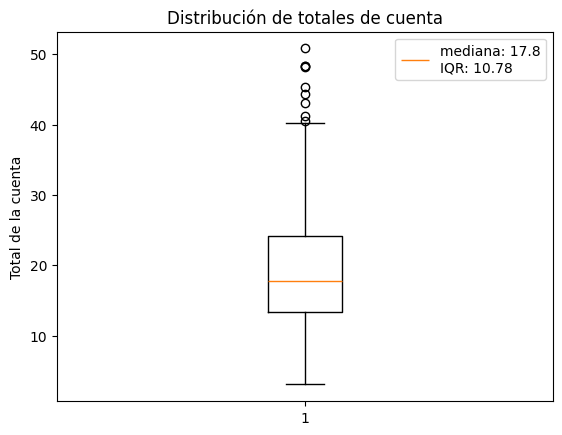

In [48]:
# Visualizar percentiles

plt.boxplot(df_tips['total_bill'], label = f'mediana: {mediana}\nIQR: {iqr}')
plt.title('Distribución de totales de cuenta')
plt.ylabel('Total de la cuenta')
plt.legend()
plt.show()

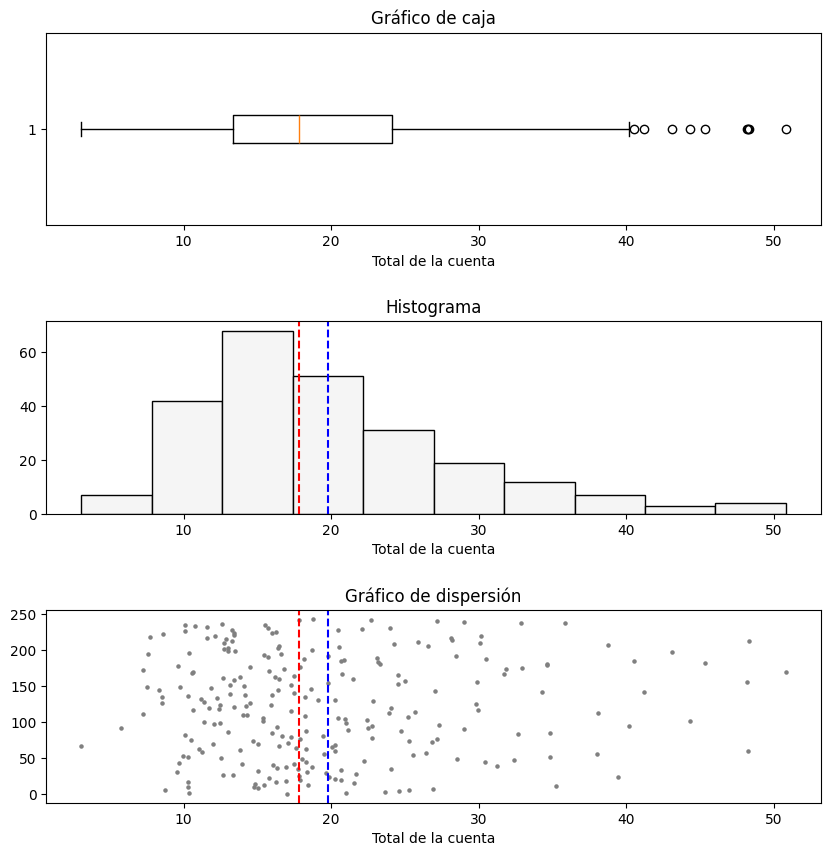

In [49]:
# Asociar gráficos

fig, ax = plt.subplots(3, figsize = (10, 10), gridspec_kw = {'hspace': 0.5})

ax[0].boxplot(df_tips['total_bill'], vert = False)
ax[0].set_title('Gráfico de caja')
ax[0].set_xlabel('Total de la cuenta')

ax[1].hist(df_tips['total_bill'], edgecolor = 'black', color = 'whitesmoke')
ax[1].axvline(x = mediana, linestyle = '--', color = 'red')
ax[1].axvline(x = media, linestyle = '--', color = 'blue')
ax[1].set_title('Histograma')
ax[1].set_xlabel('Total de la cuenta')

ax[2].scatter(y, x, s = 5, color = 'gray')
ax[2].axvline(x = mediana, linestyle = '--', color = 'red')
ax[2].axvline(x = media, linestyle = '--', color = 'blue')
ax[2].set_title('Gráfico de dispersión')
ax[2].set_xlabel('Total de la cuenta')

plt.show()

## **ANÁLISIS BIVARIABLE**

El **análisis bivariable** consiste en el estudio de la **relación entre dos variables** simultáneamente. Se utiliza para **determinar si existe una asociación, correlación o dependencia** entre ellas.

### **CORRELACIÓN**

La **correlación** es una medida estadística que **cuantifica la fuerza y la dirección de la relación** o asociación **entre dos o más variables**, describiendo de esa manera cómo el **cambio en una variable se asocia con el cambio en otra**.

**La correlación no implica causalidad**. Que dos variables cambien juntas **no significa necesariamente que una sea la causa de la otra**; ambos cambios podrían deberse a un tercer factor desconocido.

#### **MULTIVARIABLE**

Analiza la **interacción y los patrones entre tres o más variables** simultáneamente. Busca entender cómo múltiples factores influyen en un resultado o se agrupan entre sí.

Las **matrices de correlación** muestran los **coeficientes de correlación bivariados** para todos los pares posibles en un conjunto de datos grande.

In [50]:
# Definir variables

columnas = ['total_bill', 'tip', 'size']
corr = df_tips[columnas].corr()
long_col = len(columnas)

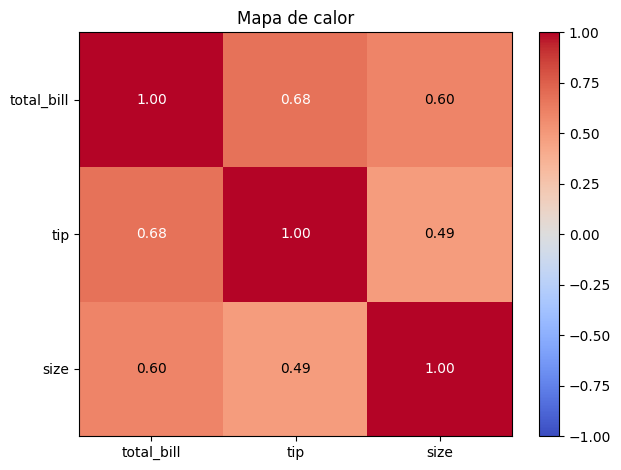

In [51]:
# Visualizar mapa de calor

corr_inv = corr.iloc[::-1]
heatmap = plt.pcolor(corr_inv, cmap = 'coolwarm', vmin = -1, vmax = 1)

plt.title('Mapa de calor')
plt.xticks(np.arange(0.5, long_col, 1), columnas)
plt.yticks(np.arange(0.5, long_col, 1), columnas[::-1])

for i in range(len(columnas)):
    for j in range(len(columnas)):
        val = round(corr_inv.iloc[i, j], 2)
        plt.text(j + 0.5, i + 0.5, f"{val:.2f}",
                 ha = 'center', va = 'center',
                 color = 'white' if abs(val) > 0.6 else 'black')

plt.colorbar(heatmap)
plt.tight_layout()
plt.show()

#### **BIVARIABLE**

Examina la **relación entre dos variables aleatorias**. Su objetivo es determinar si existe una **asociación, dirección (positiva o negativa) y fuerza**. Algunas herramientas comunes son:

*   **Coeficiente de Pearson:** Mide la fuerza de una relación lineal entre variables cuantitativas.

*   **Diagramas de dispersión:** Gráficos de "nube de puntos" que permiten visualizar la tendencia entre las dos variables.

In [52]:
# Definir variables

corr_cuenta_propina = round(df_tips['total_bill'].corr(df_tips['tip']), 2)
corr_mesa_cuenta = round(df_tips['size'].corr(df_tips['total_bill']), 2)
corr_mesa_propina = round(df_tips['size'].corr(df_tips['tip']), 2)

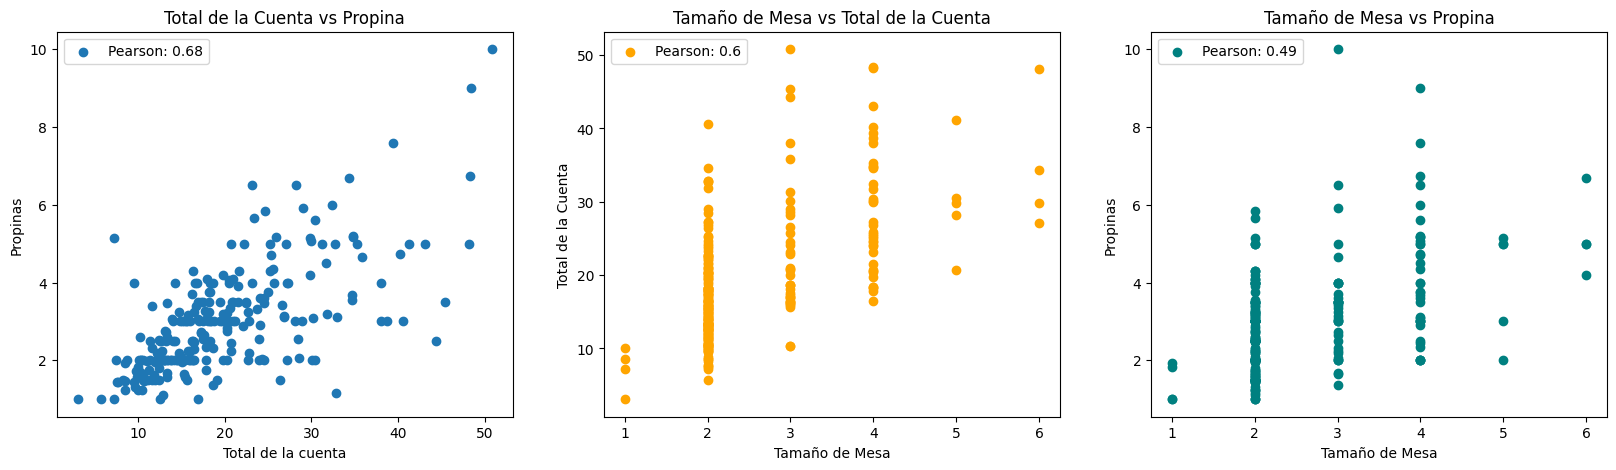

In [53]:
# Visualizar correlaciones

fig, ax = plt.subplots(1, 3, figsize=(20, 5))

ax[0].scatter(data = df_tips, x = 'total_bill', y = 'tip', label = f'Pearson: {corr_cuenta_propina}')
ax[0].set_title('Total de la Cuenta vs Propina')
ax[0].set_xlabel('Total de la cuenta')
ax[0].set_ylabel('Propinas')
ax[0].legend()

ax[1].scatter(data = df_tips, x = 'size', y = 'total_bill', color = 'Orange', label = f'Pearson: {corr_mesa_cuenta}')
ax[1].set_title('Tamaño de Mesa vs Total de la Cuenta')
ax[1].set_xlabel('Tamaño de Mesa')
ax[1].set_ylabel('Total de la Cuenta')
ax[1].legend(loc = 'upper left')

ax[2].scatter(data = df_tips, x = 'size', y = 'tip', color = 'teal', label = f'Pearson: {corr_mesa_propina}')
ax[2].set_title('Tamaño de Mesa vs Propina')
ax[2].set_xlabel('Tamaño de Mesa')
ax[2].set_ylabel('Propinas')
ax[2].legend(loc = 'upper left')

plt.show()

## **CHALLENGE: ANÁLISIS DESCRIPTIVO DE DATOS**

Una vez visto el ***Hands - On: Introducción a la estadística descriptiva***, se presentan las siguientes actividades para que el alumnado pueda repasar y reforzar lo aprendido dentro de la clase.

Dentro de la siguiente dinámica, **se realizará un análisis de estadística descriptiva** haciendo uso de **operaciones vectorizadas y visualización de datos** a través del **dataset taxis** proveniente de la librería de ***Seaborn***.

Donde los análisis a realizar son:

*   **Análisis univariable**
*   **Análisis bivariable**

**IMPORTANTE:** Para su revisión, **es indispensable que los apartados anteriores se encuentren llenados con el código visto durante la sesión.**

### **INSTRUCCIONES:**

**1. Importa las librerías:** Carga las bibliotecas de Numpy, Pandas, Seaborn y Matplotlib.pyplot.










In [54]:
# Importar librerías


In [55]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

**2. Importa el dataset de taxis:** Crea una variable denominada df_taxis donde se importe el dataset taxis.

In [56]:
# Import dataset


In [57]:
df_taxis = sns.load_dataset('taxis')
display(df_taxis.head())

,pickup,dropoff,passengers,distance,fare,tip,tolls,total,color,payment,pickup_zone,dropoff_zone,pickup_borough,dropoff_borough
0,2019-03-23 20:21:09,2019-03-23 20:27:24,1,1.60,7.0,2.15,0.0,12.95,yellow,credit card,Lenox Hill West,UN/Turtle Bay South,Manhattan,Manhattan
1,2019-03-04 16:11:55,2019-03-04 16:19:00,1,0.79,5.0,0.00,0.0,9.30,yellow,cash,Upper West Side South,Upper West Side South,Manhattan,Manhattan
2,2019-03-27 17:53:01,2019-03-27 18:00:25,1,1.37,7.5,2.36,0.0,14.16,yellow,credit card,Alphabet City,West Village,Manhattan,Manhattan
3,2019-03-10 01:23:59,2019-03-10 01:49:51,1,7.70,27.0,6.15,0.0,36.95,yellow,credit card,Hudson Sq,Yorkville West,Manhattan,Manhattan
4,2019-03-30 13:27:42,2019-03-30 13:37:14,3,2.16,9.0,1.10,0.0,13.40,yellow,credit card,Midtown East,Yorkville West,Manhattan,Manhattan


**3. Muestra los datos generales del dataset:**

   * Muestra las propiedades del dataset.
   * Muestra el resumen estadístico del dataset.

In [58]:
# Mostrar propiedades de la tabla


In [59]:
df_taxis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6433 entries, 0 to 6432
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   pickup           6433 non-null   datetime64[ns]
 1   dropoff          6433 non-null   datetime64[ns]
 2   passengers       6433 non-null   int64         
 3   distance         6433 non-null   float64       
 4   fare             6433 non-null   float64       
 5   tip              6433 non-null   float64       
 6   tolls            6433 non-null   float64       
 7   total            6433 non-null   float64       
 8   color            6433 non-null   object        
 9   payment          6389 non-null   object        
 10  pickup_zone      6407 non-null   object        
 11  dropoff_zone     6388 non-null   object        
 12  pickup_borough   6407 non-null   object        
 13  dropoff_borough  6388 non-null   object        
dtypes: datetime64[ns](2), float64(5), int64(

In [60]:
# Mostrar resumen estadístico


In [61]:
df_taxis.describe()

,pickup,dropoff,passengers,distance,fare,tip,tolls,total
count,6433,6433,6433.000000,6433.000000,6433.000000,6433.00000,6433.000000,6433.000000
mean,2019-03-16 08:31:28.514223616,2019-03-16 08:45:49.491217408,1.539251,3.024617,13.091073,1.97922,0.325273,18.517794
min,2019-02-28 23:29:03,2019-02-28 23:32:35,0.000000,0.000000,1.000000,0.00000,0.000000,1.300000
25%,2019-03-08 15:50:34,2019-03-08 16:12:51,1.000000,0.980000,6.500000,0.00000,0.000000,10.800000
50%,2019-03-15 21:46:58,2019-03-15 22:06:44,1.000000,1.640000,9.500000,1.70000,0.000000,14.160000
75%,2019-03-23 17:41:38,2019-03-23 17:51:56,2.000000,3.210000,15.000000,2.80000,0.000000,20.300000
max,2019-03-31 23:43:45,2019-04-01 00:13:58,6.000000,36.700000,150.000000,33.20000,24.020000,174.820000
std,NaN,NaN,1.203768,3.827867,11.551804,2.44856,1.415267,13.815570


**4. Realiza un análisis de univariable:**

   * Cálcula las medidas de tendencia central de la columna total.
   * Cálcula las medidas de dispersión de la columna total.
   * Visualiza los gráficos de las medidas obtenidas en un subplot de 3 columnas.

In [62]:
# Definir medidas de tendencia central


In [63]:
# Definir variables para medidas de tendencia central
media_taxis = round(df_taxis['total'].mean(), 2)
mediana_taxis = round(df_taxis['total'].median(), 2)
moda_taxis = round(df_taxis['total'].mode().iloc[0], 2)

print(f'Las MTC de la columna "total" son: media {media_taxis}, mediana {mediana_taxis} y moda {moda_taxis}')

Las MTC de la columna "total" son: media 18.52, mediana 14.16 y moda 9.3


In [64]:
# Definir medidas de dispersión


In [65]:
# Definir variables para medidas de dispersión
std_taxis = round(df_taxis['total'].std(), 2)

percentil_taxis = np.percentile(df_taxis['total'], [25, 50, 75])
q1_taxis = round(percentil_taxis[0], 2)
q3_taxis = round(percentil_taxis[2], 2)
iqr_taxis = round(q3_taxis - q1_taxis, 2)

print(f'La desviación estándar de la columna "total" es: {std_taxis}')
print(f'Los cuartiles (Q1, Q2, Q3) son: {q1_taxis}, {round(percentil_taxis[1], 2)}, {q3_taxis}')
print(f'El Rango Intercuartílico (IQR) es: {iqr_taxis}')

La desviación estándar de la columna "total" es: 13.82
Los cuartiles (Q1, Q2, Q3) son: 10.8, 14.16, 20.3
El Rango Intercuartílico (IQR) es: 9.5


In [66]:
# Definir variables


In [67]:
# Definir listas y configuraciones para visualización

x_taxis = range(len(df_taxis['total']))
y_taxis = df_taxis['total']

mtc_datos_taxis = [moda_taxis, mediana_taxis, media_taxis]
mtc_nombres_taxis = ['moda', 'mediana', 'media']
mtc_colores_taxis = ['green', 'red', 'blue']
mtc_configuraciones_taxis = zip(mtc_datos_taxis, mtc_nombres_taxis, mtc_colores_taxis)

std_datos_taxis = [media_taxis, media_taxis + std_taxis, media_taxis - std_taxis]
std_nombres_taxis = ['media', 'desviación estándar (+1 std)', 'desviación estándar (-1 std)']
std_colores_taxis = ['red', 'blue', 'blue']
std_configuraciones_taxis = zip(std_datos_taxis, std_nombres_taxis, std_colores_taxis)

In [68]:
# Visualizar medidas descriptivas


/tmp/ipykernel_1602/70299290.py:29: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


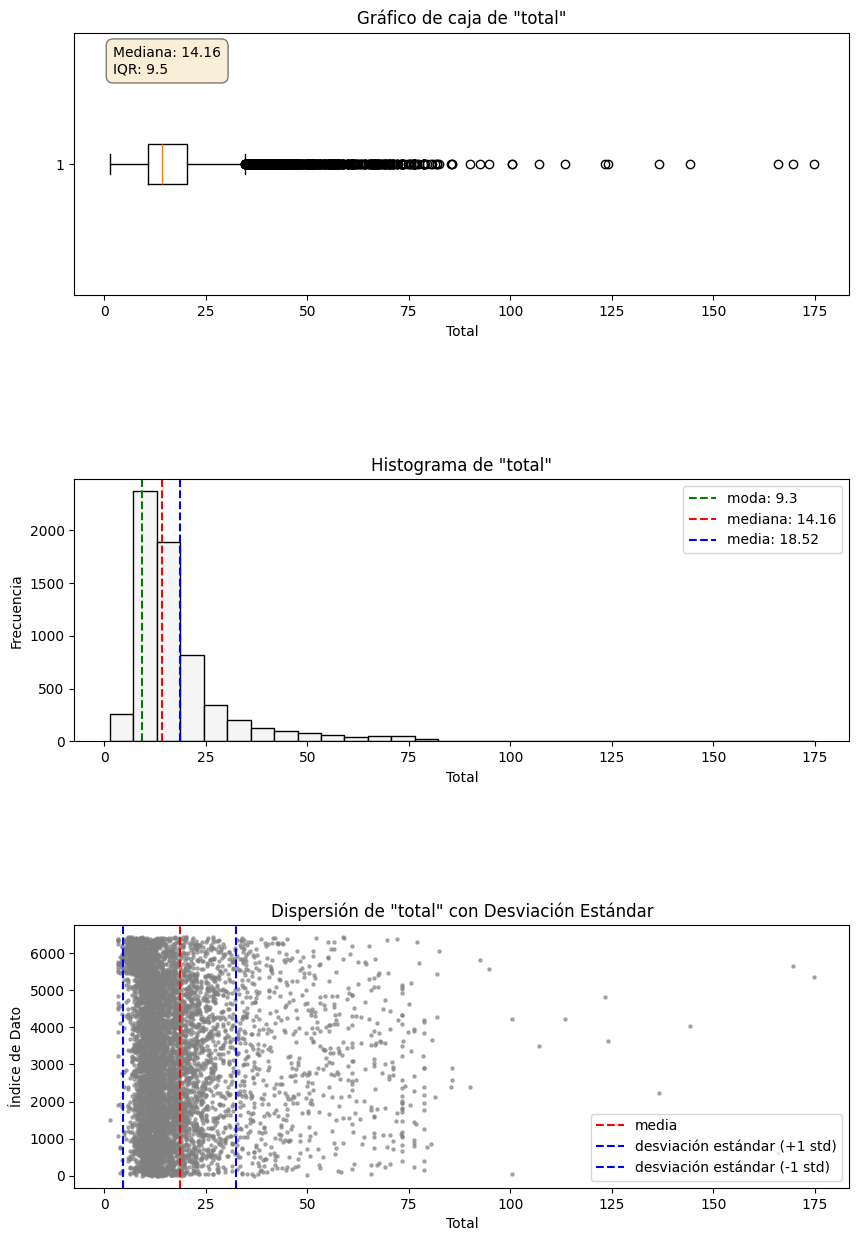

In [69]:
# Visualizar medidas descriptivas en un subplot de 3 columnas

fig, ax = plt.subplots(3, figsize = (10, 15), gridspec_kw = {'hspace': 0.7})

# Gráfico de caja
ax[0].boxplot(df_taxis['total'], vert = False)
ax[0].set_title('Gráfico de caja de "total"')
ax[0].set_xlabel('Total')
ax[0].text(0.05, 0.95, f'Mediana: {mediana_taxis}\nIQR: {iqr_taxis}', transform=ax[0].transAxes, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Histograma
ax[1].hist(df_taxis['total'], edgecolor = 'black', color = 'whitesmoke', bins=30)
ax[1].set_title('Histograma de "total"')
ax[1].set_xlabel('Total')
ax[1].set_ylabel('Frecuencia')
for dato, nombre, color in zip(mtc_datos_taxis, mtc_nombres_taxis, mtc_colores_taxis):
  ax[1].axvline(x = dato, c = color, linestyle = '--', label = f'{nombre}: {dato}')
ax[1].legend()

# Gráfico de dispersión con desviación estándar
ax[2].scatter(y_taxis, x_taxis, s = 5, color = 'gray', alpha=0.6)
ax[2].set_title('Dispersión de "total" con Desviación Estándar')
ax[2].set_xlabel('Total')
ax[2].set_ylabel('Índice de Dato')
for dato, nombre, color in std_configuraciones_taxis:
    ax[2].axvline(x = dato, c = color, linestyle = '--', label = nombre)
ax[2].legend()

plt.tight_layout()
plt.show()

**5. Realiza un análisis de multivariable:** Visualiza en un mapa de calor los coeficientes de correlación para todos los pares posibles de las columnas numéricas del dataset.

In [70]:
# Definir variables


In [71]:
# Seleccionar solo las columnas numéricas para el mapa de calor
columnas_numericas_taxis = df_taxis.select_dtypes(include=np.number).columns.tolist()
corr_taxis = df_taxis[columnas_numericas_taxis].corr()
long_col_taxis = len(columnas_numericas_taxis)

In [72]:
# Visualizar mapa de calor


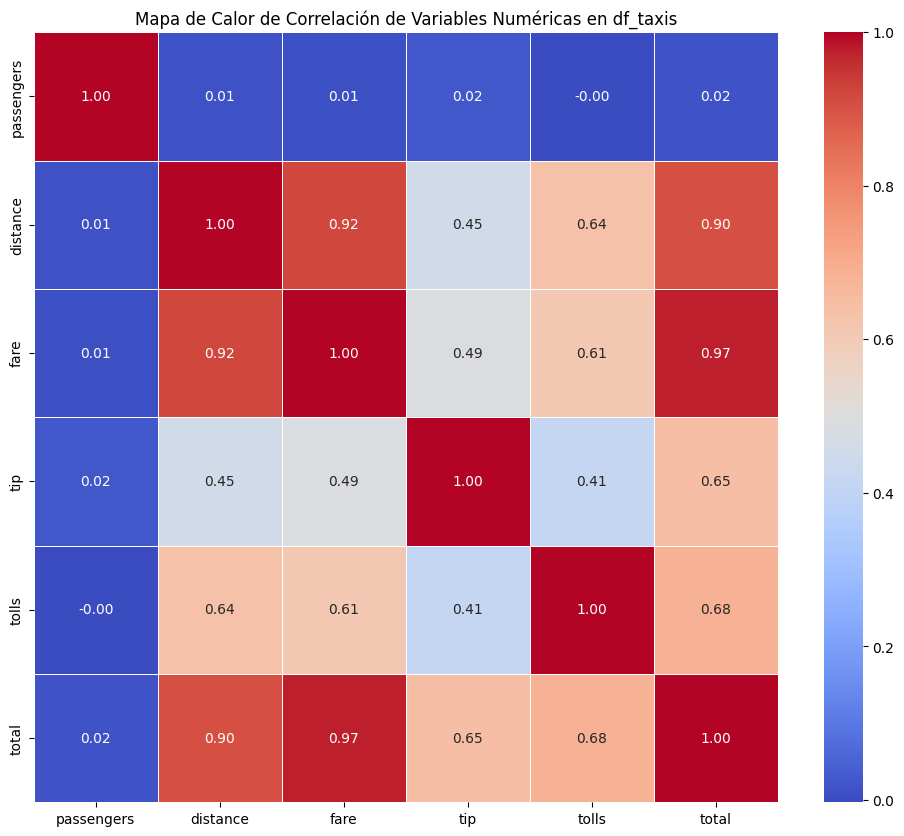

In [73]:
# Visualizar mapa de calor

plt.figure(figsize=(12, 10))
sns.heatmap(corr_taxis, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Mapa de Calor de Correlación de Variables Numéricas en df_taxis')
plt.show()

 **6. Realiza un análisis de bivariable:**

   * Cálcula los coeficientes de correlación de pearson de las 3 correlaciones mas fuertes obtenidas en el gráfico de calor.
   * Visualiza los gráficos de las correlaciones obtenidas en un subplot de 3 columnas.

In [74]:
# Definir variables


In [75]:
# Basado en el mapa de calor, identificaremos 3 de las correlaciones más fuertes y lógicas.
# Por ejemplo: 'total' vs 'fare', 'total' vs 'tip', 'distance' vs 'fare'

corr_total_fare = round(df_taxis['total'].corr(df_taxis['fare']), 2)
corr_total_tip = round(df_taxis['total'].corr(df_taxis['tip']), 2)
corr_distance_fare = round(df_taxis['distance'].corr(df_taxis['fare']), 2)

print(f'Correlación entre "total" y "fare": {corr_total_fare}')
print(f'Correlación entre "total" y "tip": {corr_total_tip}')
print(f'Correlación entre "distance" y "fare": {corr_distance_fare}')

Correlación entre "total" y "fare": 0.97
Correlación entre "total" y "tip": 0.65
Correlación entre "distance" y "fare": 0.92


In [76]:
# Visualizar correlaciones


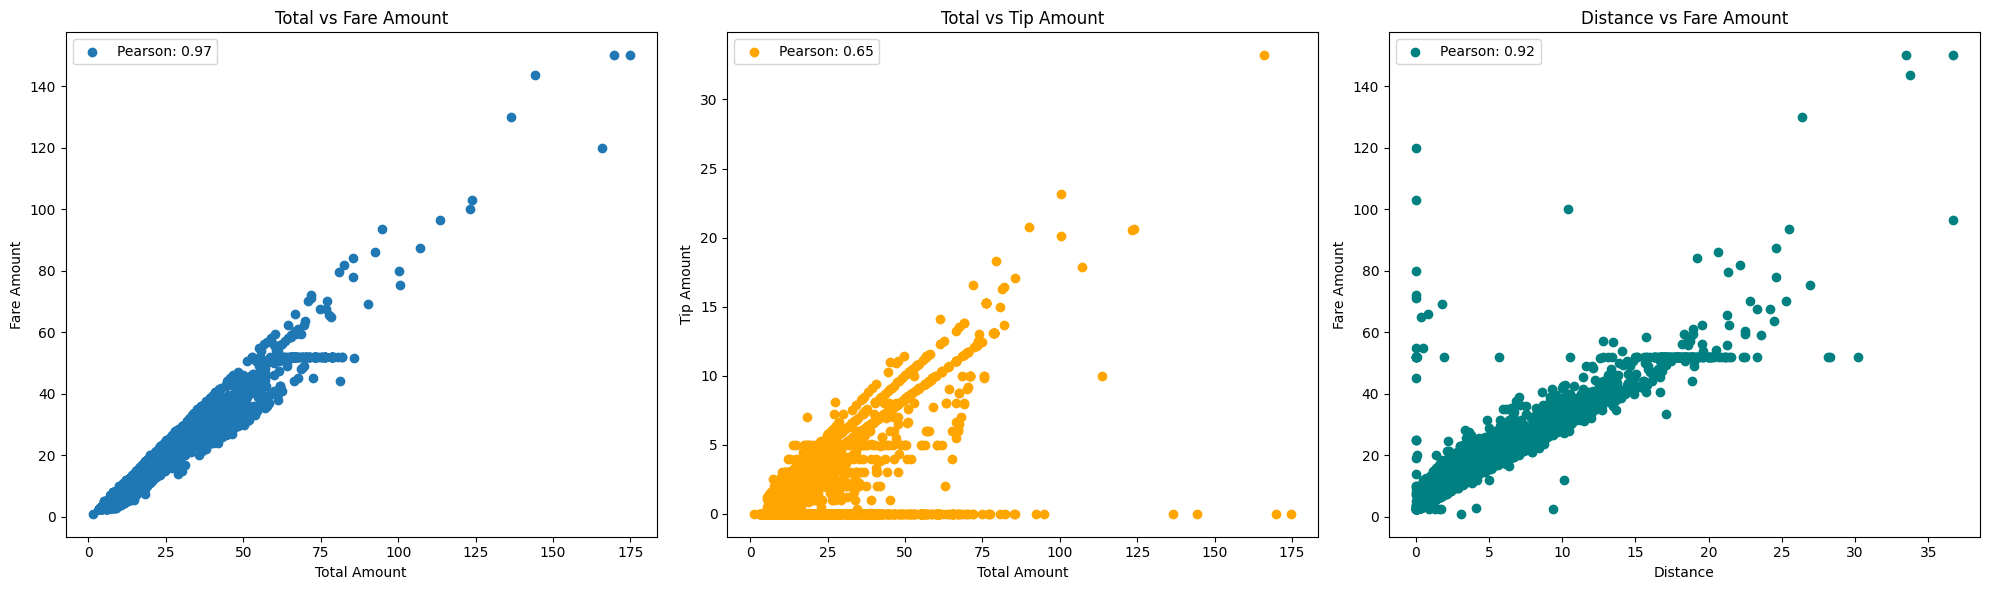

In [77]:
# Visualizar correlaciones de bivariable en un subplot de 3 columnas

fig, ax = plt.subplots(1, 3, figsize=(20, 6))

# Total vs Fare
ax[0].scatter(data = df_taxis, x = 'total', y = 'fare', label = f'Pearson: {corr_total_fare}')
ax[0].set_title('Total vs Fare Amount')
ax[0].set_xlabel('Total Amount')
ax[0].set_ylabel('Fare Amount')
ax[0].legend()

# Total vs Tip
ax[1].scatter(data = df_taxis, x = 'total', y = 'tip', color = 'Orange', label = f'Pearson: {corr_total_tip}')
ax[1].set_title('Total vs Tip Amount')
ax[1].set_xlabel('Total Amount')
ax[1].set_ylabel('Tip Amount')
ax[1].legend(loc = 'upper left')

# Trip Distance vs Fare
ax[2].scatter(data = df_taxis, x = 'distance', y = 'fare', color = 'teal', label = f'Pearson: {corr_distance_fare}')
ax[2].set_title('Distance vs Fare Amount')
ax[2].set_xlabel('Distance')
ax[2].set_ylabel('Fare Amount')
ax[2].legend(loc = 'upper left')

plt.tight_layout()
plt.show()